## **Imports**

In [1]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.1 MB/s eta 0:00:00


In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import regex as re
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import shutil
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## **The Data**

In [3]:
# load the data
df = pd.read_csv("class_df.csv")

df.head()

,Original_DataFrame_Index,Original_Text,Exposure_Score,Label_Has_PII
0,0,I hope it’s okay to gently share something her...,0.000,1
1,1,The Hanover Company is NOW HIRING! Position: ...,0.000,1
2,2,[#spamton](https://www.facebook.com/hashtag/sp...,0.125,1
3,3,good day everyone! permission to post,0.000,0
4,4,Hiring!Freshers for IT & Non-IT Technologies w...,0.000,1


In [4]:
print(df.dtypes)
print(df["Label_Has_PII"].value_counts(normalize=True))

Original_DataFrame_Index      int64
Original_Text                object
Exposure_Score              float64
Label_Has_PII                 int64
dtype: object
Label_Has_PII
1    0.878663
0    0.121337
Name: proportion, dtype: float64


--- Character Length Distribution ---
count    15527.000000
mean       432.373865
std        532.735536
min          5.000000
25%        165.000000
50%        281.000000
75%        486.000000
max      11019.000000
Name: Original_Text, dtype: float64

--- Word Count Distribution ---
count    15527.000000
mean        62.177368
std         74.641059
min          1.000000
25%         24.000000
50%         40.000000
75%         71.000000
max       1804.000000
Name: Original_Text, dtype: float64


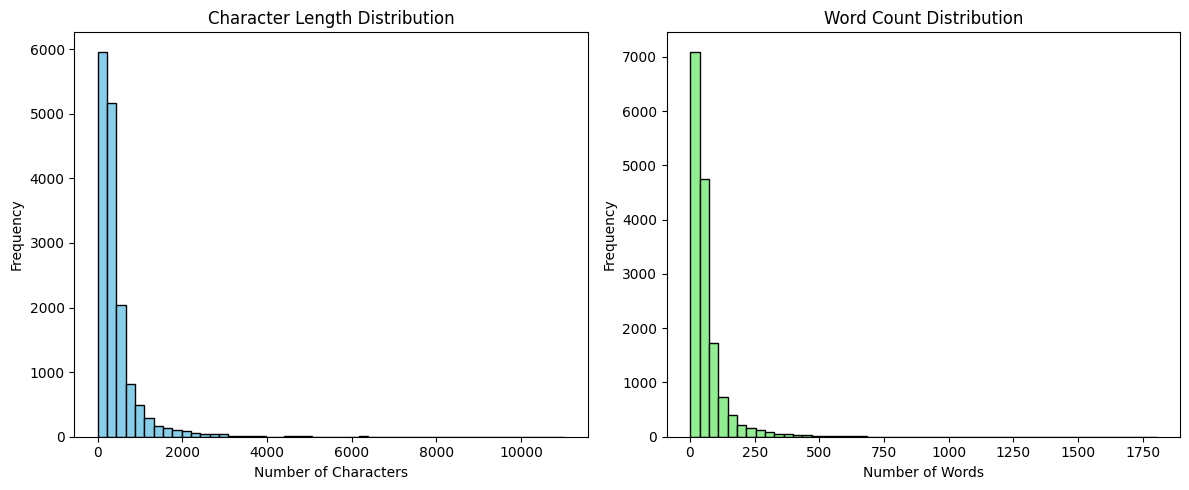

In [5]:
import matplotlib.pyplot as plt

# Calculate lengths
char_lengths = df["Original_Text"].apply(len)
word_lengths = df["Original_Text"].apply(lambda x: len(str(x).split()))

# Print statistics
print("--- Character Length Distribution ---")
print(char_lengths.describe())
print("\n--- Word Count Distribution ---")
print(word_lengths.describe())

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(char_lengths, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

axes[1].hist(word_lengths, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## **Feature Engineering**

In [6]:
# ============================================================================
# FEATURE ENGINEERING (numeric features derived from the raw text)
# ============================================================================
# Two kinds of features:
#   (A) Length/digit statistics  -- cheap, general signal.
#   (B) Structural regex patterns -- catch PII shapes the Bag-of-Words CANNOT
#       see (a phone is a *pattern* of digits, not a vocabulary word).
#
# Patterns were validated on the real data first:
#   - email  : 1,535 posts matched, ~100% are PII  -> KEEP
#   - phone  : 1,053 posts matched (tightened regex), ~100% PII -> KEEP
#   - crypto : only 1 post in the whole dataset     -> DROP (no signal)
#   - coords : 0 posts in any format                -> DROP (not present)
# Redundant math features (sum/avg of digits) were also dropped.
# ============================================================================

# Clean target columns and ensure text is string
df = df.dropna(subset=["Original_Text", "Label_Has_PII"])
df["Original_Text"] = df["Original_Text"].astype(str)

# ---- (A) Length & digit statistics ----------------------------------------
df['word_count']     = df['Original_Text'].apply(lambda x: len(x.split()))
df['char_count']     = df['Original_Text'].apply(lambda x: len(x))
df['log_char_count'] = np.log1p(df['char_count'])          # tame the long tail
df['has_numbers']    = df['Original_Text'].apply(lambda x: 1 if re.search(r'\d', x) else 0)
df['digit_count']    = df['Original_Text'].apply(lambda x: len(re.findall(r'\d', x)))
df['non_digit_count'] = df['char_count'] - df['digit_count']
# Kept (non-linear, not a duplicate of char_count):
df['digits_non_digits_product'] = df['digit_count'] * df['non_digit_count']

# ---- (B) Structural PII patterns (regex) ----------------------------------
# Email: user@domain.tld
EMAIL_RE = re.compile(r'[A-Za-z0-9._%+\-]+@[A-Za-z0-9.\-]+\.[A-Za-z]{2,}')

# Phone: optional +country code, then groups of digits separated by space/./-
# Requiring separators avoids matching prices, dates, long ID strings, etc.
PHONE_RE = re.compile(
    r'(?:\+\d{1,3}[\s.\-]?)?\(?\d{2,4}\)?[\s.\-]\d{2,4}[\s.\-]\d{2,4}(?:[\s.\-]\d{2,4})?'
)

# Count of matches (richer than a 0/1 flag: spam often has several)
df['email_count'] = df['Original_Text'].apply(lambda x: len(EMAIL_RE.findall(x)))
df['phone_count'] = df['Original_Text'].apply(lambda x: len(PHONE_RE.findall(x)))
# Binary presence flags too (sometimes "any" is the cleaner signal)
df['has_email'] = (df['email_count'] > 0).astype(int)
df['has_phone'] = (df['phone_count'] > 0).astype(int)

# ----------------------------------------------------------------------------
# Single source of truth: which numeric features feed the model.
# Edit THIS list to experiment (add/remove in one place).
# ----------------------------------------------------------------------------
NUMERIC_FEATURES = [
    'Exposure_Score',            # original real engagement signal
    'word_count',
    'char_count',
    'log_char_count',
    'has_numbers',
    'digit_count',
    'non_digit_count',
    'digits_non_digits_product',
    'email_count',               # structural PII pattern
    'phone_count',               # structural PII pattern
    'has_email',
    'has_phone',
]

print("Numeric features feeding the model:", len(NUMERIC_FEATURES))
print(NUMERIC_FEATURES)
print("\nFeature statistics:")
display(df[NUMERIC_FEATURES].describe())
display(df.head(3))

Numeric features feeding the model: 12
['Exposure_Score', 'word_count', 'char_count', 'log_char_count', 'has_numbers', 'digit_count', 'non_digit_count', 'digits_non_digits_product', 'email_count', 'phone_count', 'has_email', 'has_phone']

Feature statistics:


,Exposure_Score,word_count,char_count,log_char_count,has_numbers,digit_count,non_digit_count,digits_non_digits_product,email_count,phone_count,has_email,has_phone
count,15527.000000,15527.000000,15527.000000,15527.000000,15527.000000,15527.000000,15527.000000,1.552700e+04,15527.000000,15527.000000,15527.000000,15527.000000
mean,0.393822,62.177368,432.373865,5.645308,0.727120,10.436208,421.937657,1.032256e+04,0.112642,0.073614,0.098860,0.067817
std,0.972509,74.641059,532.735536,0.911365,0.445454,27.580814,520.775794,1.561403e+05,0.360699,0.289458,0.298484,0.251440
min,0.000000,1.000000,5.000000,1.791759,0.000000,0.000000,3.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000000,24.000000,165.000000,5.111988,0.000000,0.000000,159.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,0.375000,40.000000,281.000000,5.641907,1.000000,5.000000,274.000000,1.174000e+03,0.000000,0.000000,0.000000,0.000000
75%,0.625000,71.000000,486.000000,6.188264,1.000000,12.000000,476.000000,4.510000e+03,0.000000,0.000000,0.000000,0.000000
max,66.875000,1804.000000,11019.000000,9.307467,1.000000,1677.000000,10917.000000,1.516343e+07,4.000000,6.000000,1.000000,1.000000


,Original_DataFrame_Index,Original_Text,Exposure_Score,Label_Has_PII,word_count,char_count,log_char_count,has_numbers,digit_count,non_digit_count,digits_non_digits_product,email_count,phone_count,has_email,has_phone
0,0,I hope it’s okay to gently share something her...,0.000,1,136,810,6.698268,0,0,810,0,0,0,0,0
1,1,The Hanover Company is NOW HIRING! Position: ...,0.000,1,157,1059,6.966024,1,21,1038,21798,0,1,0,1
2,2,[#spamton](https://www.facebook.com/hashtag/sp...,0.125,1,32,9351,9.143346,1,1266,8085,10235610,0,0,0,0


## **Stratified Split & Directory Creation**

In [7]:
# ============================================================================
# STRATIFIED 3-WAY SPLIT  (train / val / test)
# ============================================================================
# Stratified on the label so the natural ~7:1 ratio is preserved in every split.
# After this point: any fitting (vectorizer adapt, scaler fit, class weights,
# oversampling) is done on TRAIN ONLY. val/test keep their natural distribution.
# ============================================================================

from sklearn.model_selection import train_test_split

CONFIG = {
    "batch_size": 32,
    "random_state": 42,
    "text_col": "Original_Text",
    "label_col": "Label_Has_PII",
}

# Split 1: (Train+Val) 85%  vs  Test 15%
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df[CONFIG['label_col']],
    random_state=CONFIG['random_state'],
)

# Split 2: from the 85%, carve out Val so final ratios are ~70/15/15.
# 0.1765 * 0.85 ≈ 0.15 of the total.
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    stratify=train_val_df[CONFIG['label_col']],
    random_state=CONFIG['random_state'],
)

# Reset positional index so text / numeric / labels stay row-aligned downstream.
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ---- Sanity checks ---------------------------------------------------------
print("Split sizes -> train:", len(train_df),
      "| val:", len(val_df), "| test:", len(test_df))

print("\nLabel ratio per split (should all be ≈ 0.88 / 0.12):")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    ratios = d[CONFIG['label_col']].value_counts(normalize=True).round(3).to_dict()
    print(f"  {name:5s}: {ratios}")

# Save for reproducibility / inspection (optional)
train_df.to_csv("train_features.csv", index=True)
val_df.to_csv("val_features.csv", index=True)
test_df.to_csv("test_features.csv", index=True)
print("\nFeature CSVs saved.")

Split sizes -> train: 10867 | val: 2330 | test: 2330

Label ratio per split (should all be ≈ 0.88 / 0.12):
  train: {1: 0.879, 0: 0.121}
  val  : {1: 0.879, 0: 0.121}
  test : {1: 0.879, 0: 0.121}

Feature CSVs saved.


## **Preprocessing & Tokenization**

In [9]:
# ============================================================================
# TEXT PREPROCESSING & VECTORIZATION  (Bag of Words)
# ============================================================================
# Three stages:
#   1. Preprocess each split's text (lowercase, isolate symbols, stem).
#   2. adapt() the vocabulary on TRAIN ONLY  -> no leakage from val/test.
#   3. Vectorize all three splits into ALIGNED arrays (row order preserved),
#      so text stays synced with the numeric features and labels.
# ============================================================================

from nltk.stem import SnowballStemmer

MAX_VOCAB_SIZE = 20000
stemmer = SnowballStemmer("english")

# ---- 1. Preprocessing ------------------------------------------------------
# pandas .apply needs a callable; this is a pure text transform, not pipeline
# logic. (If you want ZERO functions we can convert to an explicit for-loop,
# but it would be slower and less readable.)
def custom_preprocess(text):
    text = text.lower()
    # Pad special characters so they become standalone tokens (helps PII)
    text = re.sub(r'([!@#$%^&*(),.?":{}|<>])', r' \1 ', text)
    tokens = text.split()
    return " ".join(stemmer.stem(w) for w in tokens)

print("Preprocessing text per split...")
train_text = train_df[CONFIG["text_col"]].apply(custom_preprocess).values
val_text   = val_df[CONFIG["text_col"]].apply(custom_preprocess).values
test_text  = test_df[CONFIG["text_col"]].apply(custom_preprocess).values

# ---- 2. Vectorizer: adapt on TRAIN ONLY ------------------------------------
vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='tf_idf',
    standardize=None,      # we already standardized in custom_preprocess
)

print("Adapting vectorizer on TRAIN text only (no leakage)...")
vectorize_layer.adapt(train_text)          # <-- TRAIN ONLY
vocab_size = len(vectorize_layer.get_vocabulary())
print("Vocabulary size after adapt:", vocab_size)

# ---- 3. Transform all splits into aligned arrays ---------------------------
X_train_text = vectorize_layer(train_text)
X_val_text   = vectorize_layer(val_text)
X_test_text  = vectorize_layer(test_text)

# Labels as plain numpy arrays, aligned with everything else
y_train = train_df[CONFIG["label_col"]].values
y_val   = val_df[CONFIG["label_col"]].values
y_test  = test_df[CONFIG["label_col"]].values

print("\nShapes (rows must match numeric features later):")
print("  X_train_text:", X_train_text.shape, "| y_train:", y_train.shape)
print("  X_val_text:  ", X_val_text.shape,   "| y_val:  ", y_val.shape)
print("  X_test_text: ", X_test_text.shape,  "| y_test: ", y_test.shape)

Preprocessing text per split...
Adapting vectorizer on TRAIN text only (no leakage)...
Vocabulary size after adapt: 20000

Shapes (rows must match numeric features later):
  X_train_text: (10867, 20000) | y_train: (10867,)
  X_val_text:   (2330, 20000) | y_val:   (2330,)
  X_test_text:  (2330, 20000) | y_test:  (2330,)


## **NUMERIC FEATURE SCALING**

In [10]:
# ============================================================================
# NUMERIC FEATURE SCALING  (RobustScaler)
# ============================================================================
# Why RobustScaler (not MinMax): the numeric features are heavily right-skewed
# with extreme outliers (e.g. Exposure_Score median=0.38 but max=66.9). MinMax
# would crush ~50% of the data into <1% of the [0,1] range. RobustScaler centers
# on the median and scales by the IQR, so single extreme values barely move it.
#
# Same leakage rule as before: FIT on TRAIN ONLY, then transform val/test.
# Feature set comes from NUMERIC_FEATURES (single source of truth).
# ============================================================================

from sklearn.preprocessing import RobustScaler

# Numeric matrices from the in-memory split DataFrames, same row order as text.
X_train_num_raw = train_df[NUMERIC_FEATURES].values
X_val_num_raw   = val_df[NUMERIC_FEATURES].values
X_test_num_raw  = test_df[NUMERIC_FEATURES].values

# Fit on TRAIN ONLY, then transform all three splits
scaler = RobustScaler()
X_train_num = scaler.fit_transform(X_train_num_raw)   # fit + transform
X_val_num   = scaler.transform(X_val_num_raw)         # transform only
X_test_num  = scaler.transform(X_test_num_raw)        # transform only

print("Numeric features scaled with RobustScaler. Using", len(NUMERIC_FEATURES), "features.")
print("  X_train_num:", X_train_num.shape)
print("  X_val_num:  ", X_val_num.shape)
print("  X_test_num: ", X_test_num.shape)

# ---- Alignment sanity check (text rows must equal numeric rows) ------------
assert X_train_num.shape[0] == X_train_text.shape[0] == y_train.shape[0], "TRAIN misaligned!"
assert X_val_num.shape[0]   == X_val_text.shape[0]   == y_val.shape[0],   "VAL misaligned!"
assert X_test_num.shape[0]  == X_test_text.shape[0]  == y_test.shape[0],  "TEST misaligned!"
print("\nAlignment check passed: text, numeric, and labels are row-synced.")

Numeric features scaled with RobustScaler. Using 12 features.
  X_train_num: (10867, 12)
  X_val_num:   (2330, 12)
  X_test_num:  (2330, 12)

Alignment check passed: text, numeric, and labels are row-synced.


## **DATA BALANCING -- DATA-LEVEL**

### **Prepare Befor Oversampling \ Undersampling**

In [11]:
# ============================================================================
# DATA BALANCING -- DATA-LEVEL strategies (prepared BEFORE training)
# ============================================================================
# Of the four strategies we compare, only the DATA-LEVEL ones belong here:
#   3. oversampling  -> duplicate minority (class 0) UP to majority size
#   4. undersampling -> cut majority (class 1) DOWN to minority size
#
# The other two are handled elsewhere (chronological honesty):
#   1. baseline      -> nothing to prepare
#   2. class_weights -> COST-LEVEL, computed & applied in the TRAINING block
#
# This cell only PREPARES index arrays; it does NOT touch X_train_text /
# X_train_num / y_train. We resample INDICES so the same selection applies to
# BOTH inputs (text + numeric), keeping them aligned. TRAIN ONLY -- val/test
# keep their natural ~7:1 ratio.
# ============================================================================

np.random.seed(CONFIG['random_state'])

# Positional indices (0..N-1) of each class within the TRAIN set
idx_class_0 = np.where(y_train == 0)[0]   # minority (no PII)
idx_class_1 = np.where(y_train == 1)[0]   # majority (has PII)

n0, n1 = len(idx_class_0), len(idx_class_1)
print(f"TRAIN class sizes -> 0 (minority): {n0} | 1 (majority): {n1}  (ratio 1:{n1/n0:.1f})")

# ---- (3) OVERSAMPLING: duplicate minority up to majority size --------------
# Sample WITH replacement (we need duplicates).
extra_idx = np.random.choice(idx_class_0, size=(n1 - n0), replace=True)
oversampled_indices = np.concatenate([idx_class_0, idx_class_1, extra_idx])
np.random.shuffle(oversampled_indices)   # mix so batches aren't label-ordered

# ---- (4) UNDERSAMPLING: cut majority down to minority size -----------------
# Sample WITHOUT replacement (a unique subset). WARNING: discards data.
kept_majority = np.random.choice(idx_class_1, size=n0, replace=False)
undersampled_indices = np.concatenate([idx_class_0, kept_majority])
np.random.shuffle(undersampled_indices)

# ---- Report ----------------------------------------------------------------
print("\nPrepared data-level index arrays:")
print(f"  oversampled_indices  -> {len(oversampled_indices)} rows "
      f"{pd.Series(y_train[oversampled_indices]).value_counts().sort_index().to_dict()}")
print(f"  undersampled_indices -> {len(undersampled_indices)} rows "
      f"{pd.Series(y_train[undersampled_indices]).value_counts().sort_index().to_dict()}")

TRAIN class sizes -> 0 (minority): 1318 | 1 (majority): 9549  (ratio 1:7.2)

Prepared data-level index arrays:
  oversampled_indices  -> 19098 rows {0: 9549, 1: 9549}
  undersampled_indices -> 2636 rows {0: 1318, 1: 1318}


## **FOCAL LOSS**

In [15]:
# ============================================================================
# FOCAL LOSS -- a 5th strategy (cost-level), aimed at the hard minority class
# ============================================================================
# Focal loss down-weights easy, already-correct examples (the abundant majority)
# so gradients focus on hard examples (the rare class 0). This can raise class-0
# performance overall, unlike threshold tuning which only trades P for R.
#   gamma: how aggressively to down-weight easy examples (2.0 is standard)
#   alpha: extra weight on the positive class; here we weight the MINORITY.
# Keras requires the loss to be a callable(y_true, y_pred) -- unavoidable.
# ============================================================================

import tensorflow as tf
from tensorflow.keras import backend as K

FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.15   # tune this; higher -> more emphasis on class 1 vs 0

def focal_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
    # p_t = predicted prob of the TRUE class
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    # alpha_t = class-dependent weight
    alpha_t = y_true * FOCAL_ALPHA + (1 - y_true) * (1 - FOCAL_ALPHA)
    # focal term down-weights easy (high p_t) examples
    loss = -alpha_t * K.pow(1 - p_t, FOCAL_GAMMA) * K.log(p_t)
    return K.mean(loss)

print("focal_loss defined. gamma =", FOCAL_GAMMA, "| alpha =", FOCAL_ALPHA)

focal_loss defined. gamma = 2.0 | alpha = 0.15


## **RESULTS COLLECTOR**

In [16]:
# ============================================================================
# RESULTS COLLECTOR -- run this ONCE before starting the experiments
# ============================================================================
# Holds validation metrics of every strategy so they don't overwrite each other.
# Re-running this cell RESETS all results, so run it only once (or to start over).
RESULTS = {}
print("Results collector initialized (empty).")

Results collector initialized (empty).


## **HYBRID MODEL**

In [52]:
# ============================================================================
# HYBRID MODEL -- fully configurable via MODEL_CONFIG
# ============================================================================
# Experiment by editing MODEL_CONFIG ONLY. No need to touch the build code.
#   - Add/remove layers : add/remove numbers in the *_layers lists.
#   - Change width       : change the numbers (e.g. 128 -> 256).
#   - Change dropout     : change the *_dropout values (0.0 disables it).
# Lists are read left-to-right as consecutive Dense layers in that branch.
# ============================================================================

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

# ----------------------------- THE CONTROL PANEL ----------------------------
MODEL_CONFIG = {
    # Branch A: text (Bag of Words) -- usually wider (richer input)
    "text_layers":   [128, 64, 64],     # one Dense per number; [] = no hidden layers
    "text_dropout":  0.5,           # applied after each text layer

    # Branch B: numeric features -- usually smaller
    "num_layers":    [128, 64, 64],
    "num_dropout":   0.5,

    # Fusion head (after concatenating the two branches)
    "head_layers":   [32],
    "head_dropout":  0.5,

    # Optimizer
    "learning_rate": 1e-3,
}
# ----------------------------------------------------------------------------

text_dim = X_train_text.shape[1]
num_dim  = X_train_num.shape[1]
print(f"Text input dim: {text_dim} | Numeric input dim: {num_dim}")

# ---- Branch A: text --------------------------------------------------------
text_input = layers.Input(shape=(text_dim,), name="text_input")
x = text_input
for i, units in enumerate(MODEL_CONFIG["text_layers"]):
    x = layers.Dense(units, activation="relu", name=f"text_dense_{i}")(x)
    if MODEL_CONFIG["text_dropout"] > 0:
        x = layers.Dropout(MODEL_CONFIG["text_dropout"], name=f"text_drop_{i}")(x)
text_repr = x

# ---- Branch B: numeric -----------------------------------------------------
num_input = layers.Input(shape=(num_dim,), name="numeric_input")
n = num_input
for i, units in enumerate(MODEL_CONFIG["num_layers"]):
    n = layers.Dense(units, activation="relu", name=f"num_dense_{i}")(n)
    if MODEL_CONFIG["num_dropout"] > 0:
        n = layers.Dropout(MODEL_CONFIG["num_dropout"], name=f"num_drop_{i}")(n)
num_repr = n

# ---- Fusion + head ---------------------------------------------------------
combined = layers.Concatenate(name="fusion")([text_repr, num_repr])
h = combined
for i, units in enumerate(MODEL_CONFIG["head_layers"]):
    h = layers.Dense(units, activation="relu", name=f"head_dense_{i}")(h)
    if MODEL_CONFIG["head_dropout"] > 0:
        h = layers.Dropout(MODEL_CONFIG["head_dropout"], name=f"head_drop_{i}")(h)
output = layers.Dense(1, activation="sigmoid", name="pii_output")(h)

# ---- Assemble & compile ----------------------------------------------------
model = Model(inputs=[text_input, num_input], outputs=output)
model.compile(
    optimizer=Adam(learning_rate=MODEL_CONFIG["learning_rate"]),
    loss="focal_loss", # focal_loss, binary_crossentropy
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

model.summary()

Text input dim: 20000 | Numeric input dim: 12


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 20000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dense_0        │ (None, 128)       │  2,560,128 │ text_input[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense_0 (Dense) │ (None, 128)       │      1,664 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_drop_0         │ (None, 128)       │          0 │ text_dense_0[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_drop_0          │ (None, 128)       │          0 │ num_dense_0[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dense_1        │ (None, 64)        │      8,256 │ text_drop_0[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense_1 (Dense) │ (None, 64)        │      8,256 │ num_drop_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_drop_1         │ (None, 64)        │          0 │ text_dense_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_drop_1          │ (None, 64)        │          0 │ num_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dense_2        │ (None, 64)        │      4,160 │ text_drop_1[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense_2 (Dense) │ (None, 64)        │      4,160 │ num_drop_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_drop_2         │ (None, 64)        │          0 │ text_dense_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_drop_2          │ (None, 64)        │          0 │ num_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 128)       │          0 │ text_drop_2[0][0… │
│ (Concatenate)       │                   │            │ num_drop_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_0        │ (None, 32)        │      4,128 │ fusion[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop_0         │ (None, 32)        │          0 │ head_dense_0[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pii_output (Dense)  │ (None, 1)         │         33 │ head_drop_0[0][0

 Total params: 2,590,785 (9.88 MB)

 Trainable params: 2,590,785 (9.88 MB)

 Non-trainable params: 0 (0.00 B)

## **TRAINING**

In [53]:
# ============================================================================
# TRAINING -- pick ONE strategy, run, record results, repeat for the next
# ============================================================================
#   "baseline"      -> original train data, no balancing
#   "class_weights" -> original train data + class_weight in fit (cost-level)
#   "oversampling"  -> train data indexed by oversampled_indices
#   "undersampling" -> train data indexed by undersampled_indices
# val/test are NEVER rebalanced.
# ============================================================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

ACTIVE_STRATEGY = "focal_loss"   # <-- change this per experiment [baseline, class_weights, oversampling, undersampling, focal_loss]
print("=== Active strategy:", ACTIVE_STRATEGY, "===\n")

# ---- Select training data + class_weight according to the strategy ---------
fit_class_weight = None

if ACTIVE_STRATEGY == "baseline":
    Xt_tr, Xn_tr, y_tr = X_train_text, X_train_num, y_train

elif ACTIVE_STRATEGY == "class_weights":
    Xt_tr, Xn_tr, y_tr = X_train_text, X_train_num, y_train
    w = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    fit_class_weight = {0: w[0], 1: w[1]}
    print("Using class weights:", fit_class_weight)

elif ACTIVE_STRATEGY == "oversampling":
    idx = oversampled_indices
    Xt_tr, Xn_tr, y_tr = X_train_text.numpy()[idx], X_train_num[idx], y_train[idx]

elif ACTIVE_STRATEGY == "undersampling":
    idx = undersampled_indices
    Xt_tr, Xn_tr, y_tr = X_train_text.numpy()[idx], X_train_num[idx], y_train[idx]

elif ACTIVE_STRATEGY == "focal_loss":
    Xt_tr, Xn_tr, y_tr = X_train_text, X_train_num, y_train
    # focal loss is applied by RE-COMPILING the model with it.
    # (Run the MODEL cell first for a clean model, then this.)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=MODEL_CONFIG["learning_rate"]),
        loss=focal_loss,
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.AUC(name="auc")],
    )
    print("Recompiled model with focal_loss")

else:
    raise ValueError(f"Unknown strategy: {ACTIVE_STRATEGY}")

print("Training rows:", len(y_tr),
      "| class balance:", pd.Series(y_tr).value_counts().sort_index().to_dict())

# ---- Callbacks -------------------------------------------------------------
ckpt_path = f"best_model_{ACTIVE_STRATEGY}.keras"
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=4,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(ckpt_path, monitor="val_auc", mode="max",
                    save_best_only=True, verbose=0),
]

# ---- Train -----------------------------------------------------------------
history = model.fit(
    [Xt_tr, Xn_tr], y_tr,
    validation_data=([X_val_text, X_val_num], y_val),   # natural ratio, never rebalanced
    epochs=30,
    batch_size=CONFIG["batch_size"],
    class_weight=fit_class_weight,
    callbacks=callbacks,
    verbose=1,
)
print(f"\nDone. Best model saved to: {ckpt_path}")

# ---- Evaluate on VAL and store results -------------------------------------
val_metrics = model.evaluate([X_val_text, X_val_num], y_val, verbose=0, return_dict=True)

prec = val_metrics["precision"]
rec  = val_metrics["recall"]
f1   = 2 * prec * rec / (prec + rec + 1e-8)

RESULTS[ACTIVE_STRATEGY] = {
    "accuracy":  val_metrics["accuracy"],
    "precision": prec,
    "recall":    rec,
    "f1":        f1,
    "auc":       val_metrics["auc"],
    "train_rows": len(y_tr),
}

print(f"\n[{ACTIVE_STRATEGY}] VAL metrics:")
print(f"  accuracy={val_metrics['accuracy']:.4f}  precision={prec:.4f}  "
      f"recall={rec:.4f}  f1={f1:.4f}  auc={val_metrics['auc']:.4f}")

=== Active strategy: focal_loss ===

Recompiled model with focal_loss
Training rows: 10867 | class balance: {0: 1318, 1: 9549}
Epoch 1/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7782 - auc: 0.8138 - loss: 0.0375 - precision: 0.9467 - recall: 0.7922 - val_accuracy: 0.7695 - val_auc: 0.9160 - val_loss: 0.0242 - val_precision: 0.9877 - val_recall: 0.7469
Epoch 2/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8280 - auc: 0.9056 - loss: 0.0257 - precision: 0.9768 - recall: 0.8239 - val_accuracy: 0.8270 - val_auc: 0.9311 - val_loss: 0.0214 - val_precision: 0.9847 - val_recall: 0.8158
Epoch 3/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8752 - auc: 0.9469 - loss: 0.0198 - precision: 0.9850 - recall: 0.8713 - val_accuracy: 0.8489 - val_auc: 0.9375 - val_loss: 0.0197 - val_precision: 0.9846 - val_recall: 0.8412
Epoch 4/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8994 - auc: 0.9654 - loss: 0.0155 - precision: 0.9911 - recall: 0.8936 - val_ac

## **FINAL EVALUATION**

In [54]:
# ============================================================================
# STRATEGY COMPARISON (VAL) -- each strategy at BOTH thresholds
# ============================================================================
# One unified comparison. For every trained strategy we show metrics at the
# fixed 0.5 threshold AND at the strategy's own best threshold (tuned on VAL
# for class-0 F1). Replaces all earlier comparison/minority cells.
# ============================================================================

import os
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, f1_score

ALL_STRATEGIES = ["baseline", "class_weights", "oversampling", "undersampling",
                  "focal_loss", "oversampling_focal"]
candidate_thresholds = np.linspace(0.05, 0.95, 181)
rows = []

for strat in ALL_STRATEGIES:
    ckpt = f"best_model_{strat}.keras"
    if not os.path.exists(ckpt):
        continue
    m = load_model(ckpt, custom_objects={"focal_loss": focal_loss}) if "focal" in strat \
        else load_model(ckpt)
    val_probs = m.predict([X_val_text, X_val_num], verbose=0).ravel()

    # --- at fixed 0.5 ---
    preds_05 = (val_probs >= 0.5).astype(int)
    p5, r5, f5, _ = precision_recall_fscore_support(y_val, preds_05, labels=[0, 1], zero_division=0)

    # --- at this strategy's own best threshold (max class-0 F1) ---
    c0_f1s = [f1_score(y_val, (val_probs >= t).astype(int), pos_label=0, zero_division=0)
              for t in candidate_thresholds]
    best_t = candidate_thresholds[int(np.argmax(c0_f1s))]
    preds_bt = (val_probs >= best_t).astype(int)
    pb, rb, fb, _ = precision_recall_fscore_support(y_val, preds_bt, labels=[0, 1], zero_division=0)
    _, _, fmacro, _ = precision_recall_fscore_support(y_val, preds_bt, average="macro", zero_division=0)

    rows.append({
        "strategy": strat,
        "c0_f1@0.5":  f5[0],                 # quick fixed-threshold view
        "best_thr":   best_t,                # tuned threshold
        "c0_prec":    pb[0], "c0_rec": rb[0], "c0_f1": fb[0],   # at best_thr
        "c1_f1":      fb[1],
        "macro_f1":   fmacro,
        "accuracy":   accuracy_score(y_val, preds_bt),
    })

comparison = pd.DataFrame(rows).set_index("strategy").sort_values("c0_f1", ascending=False)
print("Strategy comparison on VAL (metrics at each strategy's OWN best threshold):\n")
display(comparison.round(4))
print(f"\nBest class-0 F1: {comparison['c0_f1'].idxmax()} | "
      f"Best macro-F1: {comparison['macro_f1'].idxmax()}")

Strategy comparison on VAL (metrics at each strategy's OWN best threshold):



,c0_f1@0.5,best_thr,c0_prec,c0_rec,c0_f1,c1_f1,macro_f1,accuracy
strategy,,,,,,,,
baseline,0.6441,0.655,0.6038,0.7809,0.6810,0.9484,0.8147,0.9112
class_weights,0.6647,0.325,0.6395,0.7208,0.6777,0.9522,0.8150,0.9167
oversampling,0.6388,0.830,0.5946,0.7774,0.6738,0.9468,0.8103,0.9086
focal_loss,0.6571,0.460,0.6046,0.7456,0.6677,0.9479,0.8078,0.9099
undersampling,0.5851,0.140,0.6023,0.7385,0.6635,0.9474,0.8054,0.9090



Best class-0 F1: baseline | Best macro-F1: class_weights


# סיכום ניסויים — זיהוי PII (Label_Has_PII)

> מסמך שימור ידע. מטרה: לזכור מה ניסינו, מה עבד, ומה כבר נפסל.

## המשימה והדאטה
- **מטרה:** סיווג בינארי — האם טקסט מכיל PII (1) או לא (0).
- **חוסר איזון:** ~88% מחלקה 1, ~12% מחלקה 0. **מחלקת המיעוט היא 0 (אין PII)** — זו המחלקה הקשה.
- **פיצול:** train/val/test ביחס ~70/15/15, stratified. val/test שומרים על היחס הטבעי ולא מאוזנים אף פעם.
- **מטריקת יעד:** F1 ו-macro-F1 על **מחלקה 0** (per project goal: לצמצם החזרות שווא על טקסטים נקיים).

## המודל
- **היברידי, late fusion:** ענף טקסט (Bag-of-Words, `output_mode='count'`, vocab 20K, adapt על train בלבד) + ענף פיצ'רים מספריים (RobustScaler, fit על train בלבד).
- ארכיטקטורה נשלטת מ-`MODEL_CONFIG` (שכבות/dropout/lr גמישים).

## פיצ'רים מספריים (אחרי ניקוי)
- בסיס: word_count, char_count, log_char_count, has_numbers, digit_count, non_digit_count, digits_non_digits_product.
- **regex מבני (BoW לא תופס):** email_count/has_email, phone_count/has_phone — שניהם ~100% PII בדאטה, נשמרו.
- **נפסלו:** crypto (רק דוגמה 1 בכל הדאטה), קואורדינטות (0 בדאטה), digits_non_digits_sum ו-avg (זהים ל-char_count).
- gazetteers נפסלו (כפילות מול BoW).

## אסטרטגיות איזון שנבחנו (3 רמות)
- **data-level:** oversampling (שכפול מיעוט), undersampling (קיצוץ רוב).
- **cost-level:** class_weights, focal_loss (alpha/gamma — **כרגע קבועים: alpha=0.15, gamma=2.0, עוד לא כוונן**).
- **threshold-level:** כיוונון סף על val (אחרי האימון).
- צירופים: oversampling+focal אפשרי והגיוני. oversampling+undersampling — בלתי אפשרי. cost+cost (class_weights+focal) — כפל מיותר.

## תוצאות מפתח (VAL, class-0)
**סף קבוע 0.5:** כל האסטרטגיות בטווח class-0 F1 = 0.64–0.67. oversampling/focal מובילים באיזון; class_weights/undersampling מובילים ב-recall.

**כל אסטרטגיה בסף האופטימלי שלה (class-0 F1):**

| אסטרטגיה | best_thr | c0_f1 | c0_rec | macro_f1 |
|---|---|---|---|---|
| class_weights | 0.170 | 0.6909 | 0.7385 | 0.8224 |
| focal_loss | 0.355 | 0.6895 | 0.6749 | **0.8238** |
| baseline | 0.645 | 0.6867 | 0.7668 | 0.8188 |
| oversampling | 0.590 | 0.6745 | 0.7138 | 0.8132 |
| undersampling | 0.190 | 0.6502 | 0.6961 | 0.7989 |

**TEST (focal_loss, סף 0.355):** class-0 F1 = 0.6714, macro avg = 0.8130, accuracy = 0.9202.

## מסקנות מרכזיות
1. **תקרה ברורה:** 5 אסטרטגיות × 3 ארכיטקטורות → כולן מתכנסות ל-class-0 F1 ≈ 0.65–0.69. זה גבול **המידע ב-BoW**, לא גבול המודל.
2. **רעש > הפרשים:** השונות בין הרצות (~0.015) גדולה מההפרש בין אסטרטגיות (~0.004). **אסור להכריז על מנצח מובהק.** כל המספרים צריכים ממוצע על 3+ הרצות.
3. **threshold tuning עובד:** נתן ל-focal loss שיפור "חינם" (0.667 → 0.689 על val).
4. **כיוונון ארכיטקטורה/אופטימייזר כנראה לא יעזור:** הדאטה לא תקוע במינימום מקומי (התכנסות עקבית), אז מומנטום וכו' לא רלוונטיים. Adam כבר כולל מומנטום.

## מה נפסל / לא שווה לחזור עליו
- ❌ הוספת שכבות / שינוי dropout — נתן שיפור לא יציב (0.6816 בהרצה אחת, 0.6655 באחרת).
- ❌ מומנטום/SGD ידני — Adam כבר עושה את זה.
- ❌ crypto/coords features, gazetteers, פיצ'רים מתמטיים מיותרים.

## מה עדיין לא מוצה (כיווני המשך)
- ⏳ כיוונון alpha/gamma של focal_loss (זול, שיפור קטן צפוי).
- ⏳ **שבירת התקרה: מעבר מ-BoW ל-TF-IDF או embeddings** — הכיוון היחיד עם פוטנציאל אמיתי (נותן מידע חדש: סדר/משמעות מילים).
- ⏳ keras tuner — רק עם מטריקה נכונה (val_auc/macro-F1) ועל דאטה מאוזן; אחרת ילמד "הכול מחלקה 1".